In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure repository root is on sys.path so `core` is importable when running this notebook
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# Imports — KalKalori BareTubeHeatExchanger test

from core.geometry.tube import BareTube
from core.geometry.bundle import TubeBundle

from core.heat_transfer.internal_flow import (
    FluidProps as TubeFluidProps,
)

from core.heat_transfer.outside_flow import (
    FluidProps as OutsideFluidProps,
)

from core.heat_transfer.streams import (
    SensibleHeatStream,
)

from core.models.bare_tube import (
    BareTubeHeatExchanger,
)

In [2]:
# Tube-side fluid (water) - manual mapping to air velocity

tube_props = TubeFluidProps(
    rho=973.0,        # kg/m3
    mu=0.00036,       # Pa*s
    k=0.67,           # W/(m*K)
    cp=4196.0        # J/(kg*K)
)

# Manual assignment of water mass flow for each air velocity [kg/s]
# Edit this list directly when testing alternative operating points.
air_water_cases = [
    (2.0, 3.0),
    (4.0, 6.0),
    (8.0, 12.0),
]

# Compatibility alias used by some downstream cells
m_dot_water = air_water_cases[0][1]

# Outside fluid properties (air) - constant physical properties, varying mass flow
outside_props_base = OutsideFluidProps(
    rho=1.16,        # kg/m3
    mu=0.00002,      # Pa*s
    k=0.03,          # W/(m*K)
    cp=1026.4        # J/(kg*K)
)

# Streams - base setup (will be updated for each case)
T_hot_in = 273.15 + 80  # K
T_cold_in = 273.15 + 20  # K

print(f"Tube-side (water):")
print(f"  rho = {tube_props.rho}, mu = {tube_props.mu}, k = {tube_props.k}, cp = {tube_props.cp}")
print("  Manual map v_air -> m_dot_water [kg/s]:")
for v_air_case, m_dot_water_case in air_water_cases:
    print(f"    {v_air_case:.1f} m/s -> {m_dot_water_case:.2f} kg/s")

print(f"\nOutside (air):")
print(f"  rho = {outside_props_base.rho}, mu = {outside_props_base.mu}, k = {outside_props_base.k}, cp = {outside_props_base.cp}")


Tube-side (water):
  rho = 973.0, mu = 0.00036, k = 0.67, cp = 4196.0
  Manual map v_air -> m_dot_water [kg/s]:
    2.0 m/s -> 3.00 kg/s
    4.0 m/s -> 6.00 kg/s
    8.0 m/s -> 12.00 kg/s

Outside (air):
  rho = 1.16, mu = 2e-05, k = 0.03, cp = 1026.4


In [3]:
# Geometry and matrix definitions (copied from bare_tube_hx_test baseline)

tube = BareTube(
    D_i=0.015,   # m
    D_o=0.018,   # m
    length_total=1.34,      # m
    length_effective=1.33,  # m
    wall_k=16.0,            # W/(m*K), steel
)

n_tubes_per_row = 20
pitch_transverse_inline = 0.025
pitch_longitudinal_inline = 0.025
pitch_transverse_staggered = 0.02
pitch_longitudinal_staggered = 0.025
n_passes_tube = 2
flow_arrangement = "counterflow"
euler_provider = "gaddis_gnielinski" # zukauskas,  gaddis_gnielinski

layouts = ["inline", "staggered"]
row_counts = [2, 6, 12]
air_velocities = [2.0, 4.0, 8.0]

print(f"Outside pressure-drop provider: {euler_provider}")

def calculate_air_mass_flow(
    n_rows: int,
    velocity: float,
    pitch_transverse: float,
    pitch_longitudinal: float,
    layout: str,
    rho_air: float = 1.16,
):
    """Calculate air mass flow for a target approach velocity and bundle geometry."""
    bundle_tmp = TubeBundle(
        tube=tube,
        n_rows=n_rows,
        n_tubes_per_row=n_tubes_per_row,
        pitch_transverse=pitch_transverse,
        pitch_longitudinal=pitch_longitudinal,
        layout=layout,
        n_passes_tube=n_passes_tube,
        flow_arrangement=flow_arrangement,
    )
    A_frontal = bundle_tmp.frontal_flow_area
    m_dot_air = rho_air * velocity * A_frontal
    return m_dot_air, A_frontal


Outside pressure-drop provider: gaddis_gnielinski


In [4]:
# Execute test matrix and collect results

results_list = []
case_number = 0

air_to_water = dict(air_water_cases)

for layout in layouts:
    for n_rows in row_counts:
        for v_air in air_velocities:
            case_number += 1

            if v_air not in air_to_water:
                raise ValueError(
                    f"Missing water mass flow for v_air={v_air}. Update air_water_cases in the setup cell."
                )
            m_dot_water_case = air_to_water[v_air]

            # Select pitches based on layout
            if layout == "inline":
                pitch_transverse = pitch_transverse_inline
                pitch_longitudinal = pitch_longitudinal_inline
            else:  # staggered
                pitch_transverse = pitch_transverse_staggered
                pitch_longitudinal = pitch_longitudinal_staggered

            # Calculate air mass flow for this velocity and geometry
            m_dot_air, A_frontal = calculate_air_mass_flow(
                n_rows=n_rows,
                velocity=v_air,
                pitch_transverse=pitch_transverse,
                pitch_longitudinal=pitch_longitudinal,
                layout=layout,
            )

            try:
                # Create bundle configuration for this case
                bundle = TubeBundle(
                    tube=tube,
                    n_rows=n_rows,
                    n_tubes_per_row=n_tubes_per_row,
                    pitch_transverse=pitch_transverse,
                    pitch_longitudinal=pitch_longitudinal,
                    layout=layout,
                    n_passes_tube=n_passes_tube,
                    flow_arrangement=flow_arrangement,
                )

                # Create streams for this case
                hot_stream = SensibleHeatStream(
                    C=m_dot_water_case * tube_props.cp,
                    T_in=T_hot_in,
                )

                cold_stream = SensibleHeatStream(
                    C=m_dot_air * outside_props_base.cp,
                    T_in=T_cold_in,
                )

                # Create and solve heat exchanger model
                hx = BareTubeHeatExchanger(bundle=bundle)
                result = hx.solve(
                    hot_stream=hot_stream,
                    cold_stream=cold_stream,
                    m_dot_tube_side=m_dot_water_case,
                    tube_side_props=tube_props,
                    m_dot_outside=m_dot_air,
                    outside_props=outside_props_base,
                    euler_provider=euler_provider,
                )

                # Store result
                results_list.append(
                    {
                        "case": case_number,
                        "layout": layout,
                        "n_rows": n_rows,
                        "n_tubes_total": bundle.n_tubes_total,
                        "v_air": v_air,
                        "m_dot_air": m_dot_air,
                        "m_dot_water": m_dot_water_case,
                        "A_frontal": A_frontal,
                        "T_hot_in": T_hot_in,
                        "T_cold_in": T_cold_in,
                        "UA": result.UA,
                        "eps": result.eps,
                        "Q": result.Q,
                        "T_hot_out": result.T_hot_out,
                        "T_cold_out": result.T_cold_out,
                        "v_tube_side": result.tube_side_thermal.v,
                        "Re_tube_side": result.tube_side_thermal.Re,
                        "h_tube_side": result.tube_side_thermal.alfa,
                        "dp_tube_side": result.tube_side_hydraulic.dp_total,
                        "v_outside": result.outside_side_thermal.v,
                        "Re_outside": result.outside_side_thermal.Re,
                        "h_outside": result.outside_side_thermal.alfa,
                        "dp_outside": result.outside_side_hydraulic.dp_total,
                        "A_i": result.A_i,
                        "A_o": result.A_o,
                        "warnings": result.warnings,
                    }
                )

                print(
                    f"Case {case_number:2d}: {layout:10s} | rows={n_rows:2d} | v_air={v_air}m/s | "
                    f"provider={euler_provider} | m_dot_air={m_dot_air:.3f} kg/s | "
                    f"m_dot_w={m_dot_water_case:.2f} kg/s | A_i={result.A_i:.2f} m2 | "
                    f"A_o={result.A_o:.2f} m2 | v_w={result.tube_side_thermal.v:.2f} m/s | "
                    f"h_out={result.outside_side_thermal.alfa:.1f} W/m2K | "
                    f"UA={result.UA:7.1f} W/K | eps={result.eps:.3f} | Q={result.Q:7.0f} W"
                )

            except Exception as e:
                print(
                    f"Case {case_number:2d}: {layout:10s} | rows={n_rows:2d} | v_air={v_air}m/s | ERROR: {e}"
                )
                results_list.append(
                    {
                        "case": case_number,
                        "layout": layout,
                        "n_rows": n_rows,
                        "v_air": v_air,
                        "error": str(e),
                    }
                )

print(f"\nCompleted {case_number} test cases")

Case  1: inline     | rows= 2 | v_air=2.0m/s | ERROR: Unknown euler_provider='gaddis_gnielinski'. Supported built-in providers: 'zukauskas', 'esdu', or pass a custom provider object implementing EulerProvider.
Case  2: inline     | rows= 2 | v_air=4.0m/s | ERROR: Unknown euler_provider='gaddis_gnielinski'. Supported built-in providers: 'zukauskas', 'esdu', or pass a custom provider object implementing EulerProvider.
Case  3: inline     | rows= 2 | v_air=8.0m/s | ERROR: Unknown euler_provider='gaddis_gnielinski'. Supported built-in providers: 'zukauskas', 'esdu', or pass a custom provider object implementing EulerProvider.
Case  4: inline     | rows= 6 | v_air=2.0m/s | ERROR: Unknown euler_provider='gaddis_gnielinski'. Supported built-in providers: 'zukauskas', 'esdu', or pass a custom provider object implementing EulerProvider.
Case  5: inline     | rows= 6 | v_air=4.0m/s | ERROR: Unknown euler_provider='gaddis_gnielinski'. Supported built-in providers: 'zukauskas', 'esdu', or pass a c

In [5]:
# Build DataFrame for downstream analysis cells

df = pd.DataFrame(results_list)

if "error" in df.columns:
    df_valid = df[df["error"].isna()].copy()
    df_errors = df[df["error"].notna()].copy()
else:
    df_valid = df.copy()
    df_errors = pd.DataFrame()

print(f"Total cases: {len(df)}")
print(f"Valid cases: {len(df_valid)}")
print(f"Failed cases: {len(df_errors)}")

preview_cols = [
    "case",
    "layout",
    "n_rows",
    "v_air",
    "m_dot_air",
    "A_i",
    "A_o",
    "v_tube_side",
    "h_outside",
    "UA",
    "eps",
    "Q",
]
available_cols = [c for c in preview_cols if c in df_valid.columns]

if available_cols and not df_valid.empty:
    print(df_valid[available_cols].head())
else:
    print("No valid result rows available for preview.")
    if not df_errors.empty:
        print("First recorded errors:")
        display(df_errors[["case", "layout", "n_rows", "v_air", "error"]].head())
    elif len(df) > 0:
        print("Available columns:", list(df.columns))

# Create a comprehensive comparison table

display_cols = [
    "case", "layout", "n_rows", "v_air", "m_dot_air", "m_dot_water",
    "A_i", "A_o",
    "v_tube_side", "h_outside",
    "UA", "eps", "Q",
    "h_tube_side", "dp_tube_side", "dp_outside",
    "T_hot_out", "T_cold_out"
]

display_cols_available = [c for c in display_cols if c in df_valid.columns]

if df_valid.empty or not display_cols_available:
    print("No valid cases to display in the comparison table.")
else:
    df_display = df_valid[display_cols_available].copy()

    round_map = {
        "m_dot_air": 3,
        "m_dot_water": 3,
        "A_i": 2,
        "A_o": 2,
        "v_tube_side": 3,
        "h_outside": 1,
        "UA": 1,
        "eps": 4,
        "Q": 0,
        "h_tube_side": 1,
        "dp_tube_side": 1,
        "dp_outside": 1,
    }
    for col, digits in round_map.items():
        if col in df_display.columns:
            df_display[col] = df_display[col].round(digits)

    if "T_hot_out" in df_display.columns:
        df_display["T_hot_out"] = (df_display["T_hot_out"] - 273.15).round(2)
    if "T_cold_out" in df_display.columns:
        df_display["T_cold_out"] = (df_display["T_cold_out"] - 273.15).round(2)

    print("Complete Results Table (all valid cases):\n")
    display(df_display)

Total cases: 18
Valid cases: 0
Failed cases: 18
No valid result rows available for preview.
First recorded errors:


,case,layout,n_rows,v_air,error
0,1,inline,2,2.0,Unknown euler_provider='gaddis_gnielinski'. Su...
1,2,inline,2,4.0,Unknown euler_provider='gaddis_gnielinski'. Su...
2,3,inline,2,8.0,Unknown euler_provider='gaddis_gnielinski'. Su...
3,4,inline,6,2.0,Unknown euler_provider='gaddis_gnielinski'. Su...
4,5,inline,6,4.0,Unknown euler_provider='gaddis_gnielinski'. Su...


No valid cases to display in the comparison table.


KeyError: 'UA'

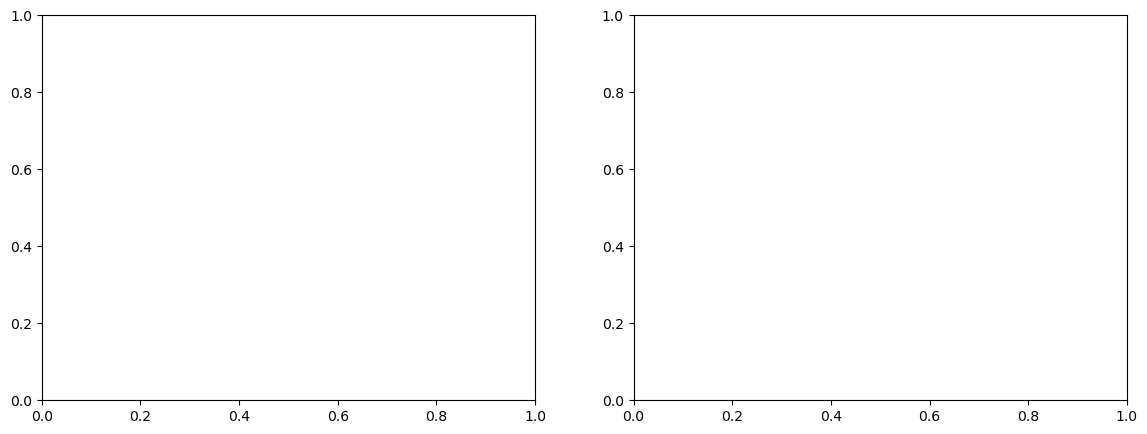

In [6]:
# Figure 1: UA vs Air Velocity (grouped by layout and rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: by layout
for layout in layouts:
    df_layout = df_valid[df_valid['layout'] == layout]
    for n_rows in row_counts:
        df_subset = df_layout[df_layout['n_rows'] == n_rows]
        axes[0].plot(df_subset['v_air'], df_subset['UA'], 'o-', 
                    label=f"{layout} ({n_rows} rows)", linewidth=2, markersize=7)

axes[0].set_xlabel('Air Velocity [m/s]', fontsize=11)
axes[0].set_ylabel('UA [W/K]', fontsize=11)
axes[0].set_title('Overall Heat Transfer Coefficient × Area vs Air Velocity', fontsize=12, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Right: effectiveness
for layout in layouts:
    df_layout = df_valid[df_valid['layout'] == layout]
    for n_rows in row_counts:
        df_subset = df_layout[df_layout['n_rows'] == n_rows]
        axes[1].plot(df_subset['v_air'], df_subset['eps'], 'o-', 
                    label=f"{layout} ({n_rows} rows)", linewidth=2, markersize=7)

axes[1].set_xlabel('Air Velocity [m/s]', fontsize=11)
axes[1].set_ylabel('Effectiveness ε', fontsize=11)
axes[1].set_title('Heat Exchanger Effectiveness vs Air Velocity', fontsize=12, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Figure 1: Performance metrics vs air velocity")

In [ ]:
# Figure 2: Heat transfer rate and outlet temperatures

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Heat transfer rate
for layout in layouts:
    df_layout = df_valid[df_valid['layout'] == layout]
    for n_rows in row_counts:
        df_subset = df_layout[df_layout['n_rows'] == n_rows]
        axes[0,0].plot(df_subset['v_air'], df_subset['Q']/1000, 'o-', 
                       label=f"{layout} ({n_rows} rows)", linewidth=2, markersize=7)

axes[0,0].set_xlabel('Air Velocity [m/s]', fontsize=11)
axes[0,0].set_ylabel('Heat Transfer Rate [kW]', fontsize=11)
axes[0,0].set_title('Heat Transfer Rate vs Air Velocity', fontsize=12, fontweight='bold')
axes[0,0].legend(loc='best')
axes[0,0].grid(True, alpha=0.3)

# Hot side outlet temperature
for layout in layouts:
    df_layout = df_valid[df_valid['layout'] == layout]
    for n_rows in row_counts:
        df_subset = df_layout[df_layout['n_rows'] == n_rows]
        axes[0,1].plot(df_subset['v_air'], df_subset['T_hot_out']-273.15, 'o-', 
                      label=f"{layout} ({n_rows} rows)", linewidth=2, markersize=7)

axes[0,1].set_xlabel('Air Velocity [m/s]', fontsize=11)
axes[0,1].set_ylabel('Hot Side Outlet Temperature [°C]', fontsize=11)
axes[0,1].set_title('Hot Stream Outlet Temperature', fontsize=12, fontweight='bold')
axes[0,1].legend(loc='best')
axes[0,1].grid(True, alpha=0.3)

# Cold side outlet temperature
for layout in layouts:
    df_layout = df_valid[df_valid['layout'] == layout]
    for n_rows in row_counts:
        df_subset = df_layout[df_layout['n_rows'] == n_rows]
        axes[1,0].plot(df_subset['v_air'], df_subset['T_cold_out']-273.15, 'o-', 
                      label=f"{layout} ({n_rows} rows)", linewidth=2, markersize=7)

axes[1,0].set_xlabel('Air Velocity [m/s]', fontsize=11)
axes[1,0].set_ylabel('Cold Side Outlet Temperature [°C]', fontsize=11)
axes[1,0].set_title('Cold Stream Outlet Temperature', fontsize=12, fontweight='bold')
axes[1,0].legend(loc='best')
axes[1,0].grid(True, alpha=0.3)

# Temperature approaches and LMTD
if 'T_hot_in' in df_valid.columns:
    th_in = df_valid['T_hot_in']
else:
    th_in = pd.Series(T_hot_in, index=df_valid.index)

if 'T_cold_in' in df_valid.columns:
    tc_in = df_valid['T_cold_in']
else:
    tc_in = pd.Series(T_cold_in, index=df_valid.index)

# Counterflow: dT1 = Th,in - Tc,out ; dT2 = Th,out - Tc,in
dt1 = th_in - df_valid['T_cold_out']
dt2 = df_valid['T_hot_out'] - tc_in
ratio = np.where(np.isclose(dt1, dt2), 1.0, dt1 / dt2)
df_valid['LMTD'] = np.where(np.isclose(dt1, dt2), dt1, (dt1 - dt2) / np.log(ratio))
df_valid['approach_hot'] = df_valid['T_hot_out'] - df_valid['T_cold_out']
df_valid['approach_cold'] = th_in - df_valid['T_cold_out']

for layout in layouts:
    df_layout = df_valid[df_valid['layout'] == layout]
    for n_rows in row_counts:
        df_subset = df_layout[df_layout['n_rows'] == n_rows]
        axes[1,1].plot(df_subset['v_air'], df_subset['approach_hot'], 'o-', 
                      label=f"{layout} ({n_rows} rows)", linewidth=2, markersize=7)

axes[1,1].set_xlabel('Air Velocity [m/s]', fontsize=11)
axes[1,1].set_ylabel('Temperature Approach Hot [K]', fontsize=11)
axes[1,1].set_title('Hot Side Temperature Approach', fontsize=12, fontweight='bold')
axes[1,1].legend(loc='best')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Figure 2: Heat transfer rates and outlet temperatures")

In [ ]:
# Figure 3: Pressure drops - air side and water side

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Air side pressure drop (linear scale)
for layout in layouts:
    df_layout = df_valid[df_valid['layout'] == layout]
    for n_rows in row_counts:
        df_subset = df_layout[df_layout['n_rows'] == n_rows]
        axes[0,0].plot(df_subset['v_air'], df_subset['dp_outside'], 'o-', 
                          label=f"{layout} ({n_rows} rows)", linewidth=2, markersize=7)

axes[0,0].set_xlabel('Air Velocity [m/s]', fontsize=11)
axes[0,0].set_ylabel('Pressure Drop [Pa]', fontsize=11)
axes[0,0].set_title('Air Side Pressure Drop (linear scale)', fontsize=12, fontweight='bold')
axes[0,0].legend(loc='best')
axes[0,0].grid(True, alpha=0.3)

# Water side pressure drop
for layout in layouts:
    df_layout = df_valid[df_valid['layout'] == layout]
    for n_rows in row_counts:
        df_subset = df_layout[df_layout['n_rows'] == n_rows]
        axes[0,1].plot(df_subset['v_air'], df_subset['dp_tube_side'], 'o-', 
                      label=f"{layout} ({n_rows} rows)", linewidth=2, markersize=7)

axes[0,1].set_xlabel('Air Velocity [m/s]', fontsize=11)
axes[0,1].set_ylabel('Pressure Drop [Pa]', fontsize=11)
axes[0,1].set_title('Water Side Pressure Drop (constant flow)', fontsize=12, fontweight='bold')
axes[0,1].legend(loc='best')
axes[0,1].grid(True, alpha=0.3)

# Heat transfer coefficients - air side
for layout in layouts:
    df_layout = df_valid[df_valid['layout'] == layout]
    for n_rows in row_counts:
        df_subset = df_layout[df_layout['n_rows'] == n_rows]
        axes[1,0].plot(df_subset['v_air'], df_subset['h_outside'], 'o-', 
                      label=f"{layout} ({n_rows} rows)", linewidth=2, markersize=7)

axes[1,0].set_xlabel('Air Velocity [m/s]', fontsize=11)
axes[1,0].set_ylabel('Heat Transfer Coefficient [W/m²K]', fontsize=11)
axes[1,0].set_title('Air Side Heat Transfer Coefficient', fontsize=12, fontweight='bold')
axes[1,0].legend(loc='best')
axes[1,0].grid(True, alpha=0.3)

# Heat transfer coefficients - water side
for layout in layouts:
    df_layout = df_valid[df_valid['layout'] == layout]
    for n_rows in row_counts:
        df_subset = df_layout[df_layout['n_rows'] == n_rows]
        axes[1,1].plot(df_subset['v_air'], df_subset['h_tube_side'], 'o-', 
                      label=f"{layout} ({n_rows} rows)", linewidth=2, markersize=7)

axes[1,1].set_xlabel('Air Velocity [m/s]', fontsize=11)
axes[1,1].set_ylabel('Heat Transfer Coefficient [W/m²K]', fontsize=11)
axes[1,1].set_title('Water Side Heat Transfer Coefficient (constant)', fontsize=12, fontweight='bold')
axes[1,1].legend(loc='best')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Figure 3: Pressure drops and heat transfer coefficients")